# Toy BNN — predictive inspection

Loads `.pt` files from `results/toy_bnns/` and plots the posterior predictive mean ± 2σ against the true function and training points, for each dataset and sampler.

In [1]:
import os
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline

if Path.cwd().name == "notebooks":
    os.chdir("..")

from sazz.gpu_friendly.scripts.toy_bnn_grid import build_target, DATASET_CONFIGS, BNNConfig
from sazz.gpu_friendly.models.neural_networks import FFN

torch.set_default_dtype(torch.float64)

RESULTS_DIR = Path("results/grid/toy_bnns")
DATA_DIR    = Path("datasets/toy_1d")

SAMPLER_STYLE = {
    "grid_boomerang":           ("C0", "Boomerang"),
    "grid_sticky_boomerang":    ("C1", "Sticky Boomerang"),
    "grid_zigzag":              ("C2", "Zig Zag"),
    "grid_sticky_zigzag":       ("C3", "Sticky Zig Zag"),
    "nuts":                     ("C4", "NUTS"),
    "svi":                      ("C5", "SVI"),
    "tf_boomerang":             ("C6", "TF Boomerang"),
    #"tf_bps":                   ("C7", "TF BPS"),
}

# Discover which (dataset, split) directories have results
available = sorted(
    (p.parent.parent.name, int(p.parent.name.split("_")[1]))
    for p in RESULTS_DIR.glob("*/split_*/grid_boomerang.pt")
)
print("Available (dataset, split):", available)


Available (dataset, split): [('gap', 0), ('hernandez', 0), ('multiscale', 0), ('sharp', 0)]


In [2]:
import torch
import numpy as np
from pathlib import Path

DATA_DIR = Path("datasets/toy_1d")

for ds in ["hernandez"]:
    d = torch.load(DATA_DIR / f"{ds}.pt", weights_only=False)
    x_raw = d["x_train_raw"]
    y_raw = d["y_train_raw"]
    print(f"=== {ds} ===")
    print(f"  n_train={d['n_train']}  x range=[{x_raw.min():.2f}, {x_raw.max():.2f}]  "
          f"x_mean={d['x_mean']:.3f}  x_std={d['x_std']:.3f}")
    print(f"  y range=[{y_raw.min():.2f}, {y_raw.max():.2f}]  "
          f"y_mean={d['y_mean']:.3f}  y_std={d['y_std']:.3f}")
    print(f"  noise_std_true={d['noise_std_true']:.4f}  "
          f"noise_std_standardised={d['noise_std']:.4f}  "
          f"signal/noise (y_std/noise_true)={d['y_std']/d['noise_std_true']:.2f}")


=== hernandez ===
  n_train=20  x range=[-3.49, 3.80]  x_mean=0.591  x_std=2.219
  y range=[-45.01, 54.03]  y_mean=4.191  y_std=21.989
  noise_std_true=3.0000  noise_std_standardised=0.1364  signal/noise (y_std/noise_true)=7.33


In [3]:
def load_split(dataset: str, split_id: int):
    """Load dataset dict and all sampler payloads for one (dataset, split)."""
    data = torch.load(DATA_DIR / f"{dataset}.pt", weights_only=False)
    split_dir = RESULTS_DIR / dataset / f"split_{split_id:02d}"
    runs = {
        p.stem: torch.load(p, weights_only=False)
        for p in sorted(split_dir.glob("*.pt"))
    }
    return data, runs


def make_bm_from_payload(payload, data, dataset: str):
    cfg = BNNConfig(**DATASET_CONFIGS[dataset], noise_std=data["noise_std"])
    bm, x_ref, Sigma_inv = build_target(data, cfg)
    return bm


@torch.no_grad()
def predictive_summary(samples: torch.Tensor, bm, payload: dict, data, x_grid: np.ndarray):
    x_mean, x_std = float(data["x_mean"]), float(data["x_std"])
    y_mean, y_std = float(data["y_mean"]), float(data["y_std"])

    X_grid = torch.tensor(x_grid[:, None], dtype=torch.float64)
    X_grid_std = (X_grid - x_mean) / x_std

    if bm.learns_noise:
        weight_samples = samples[:, :-1]
        noise_std_std_scale = float(samples[:, -1].exp().mean())  # mean sigma, standardised scale
    else:
        weight_samples = samples
        noise_std_std_scale = float(payload["noise_std"])  # fixed, already standardised scale

    preds = torch.stack([
        torch.func.functional_call(bm.module, bm.param_dict_fn(beta), (X_grid_std,)).squeeze(-1)
        for beta in weight_samples
    ])  # [S, n_grid], standardised y

    mean_std = preds.mean(0).numpy()
    epi_std  = preds.std(0).numpy()

    mean_orig  = mean_std * y_std + y_mean
    epi_orig   = epi_std * y_std
    noise_orig = noise_std_std_scale * y_std
    total_orig = np.sqrt(epi_orig**2 + noise_orig**2)
    return mean_orig, epi_orig, total_orig


In [4]:
# for dataset, split_id in available:
#     data, runs = load_split(dataset, split_id)
#     bm = make_bm_from_payload(next(iter(runs.values())), data, dataset)

#     x_test  = data["x_test_raw"]
#     y_true  = data["y_test_clean_raw"]
#     x_train = data["x_train_raw"]
#     y_train = data["y_train_raw"]

#     if dataset == "hernandez":
#         x_grid = np.sort(x_train)
#     else:
#         x_grid = np.sort(x_test)

#     sort_idx = np.argsort(x_test)
#     x_sorted = x_test[sort_idx]
#     y_sorted = y_true[sort_idx]

#     sampler_keys = [k for k in SAMPLER_STYLE if k in runs]
#     n_cols = len(sampler_keys)

#     fig, axes = plt.subplots(1, n_cols, figsize=(3.8 * n_cols, 3.6),
#                               sharey=True, squeeze=False)

#     for col, key in enumerate(sampler_keys):
#         ax = axes[0, col]
#         color, label = SAMPLER_STYLE[key]

#         payload = runs[key]
#         samples = payload["samples"]  # Tensor [S, D]
#         mean, epi, total = predictive_summary(samples, bm, payload, data, x_grid)

#         ax.fill_between(x_grid, mean - 2 * total, mean + 2 * total,
#                          color=color, alpha=0.22, linewidth=0)
#         ax.fill_between(x_grid, mean - 2 * epi, mean + 2 * epi,
#                          color=color, alpha=0.20, linewidth=0)

#         ax.plot(x_sorted, y_sorted, color="black", lw=1.4,
#                 alpha=0.8, zorder=3, label="true function")
#         ax.plot(x_grid, mean, color=color, lw=1.8, zorder=4,
#                 label="predictive mean")
#         ax.scatter(x_train, y_train, marker="x", color="black",
#                    s=40, linewidths=1.2, zorder=5, label="training data")

#         ax.set_title(label, fontsize=10)
#         ax.set_xlabel("x", fontsize=9)
#         if col == 0:
#             ax.set_ylabel("y", fontsize=9)
#         ax.tick_params(labelsize=8)
#         ax.grid(alpha=0.15, linewidth=0.5)
#         for spine in ("top", "right"):
#             ax.spines[spine].set_visible(False)

#     handles, labels = axes[0, 0].get_legend_handles_labels()
#     fig.legend(handles, labels, loc="lower center", ncol=len(handles),
#                frameon=False, fontsize=8, bbox_to_anchor=(0.5, -0.04))

#     fig.suptitle(f"{dataset}", fontsize=11, y=1.01)
#     fig.tight_layout()
#     plt.show()

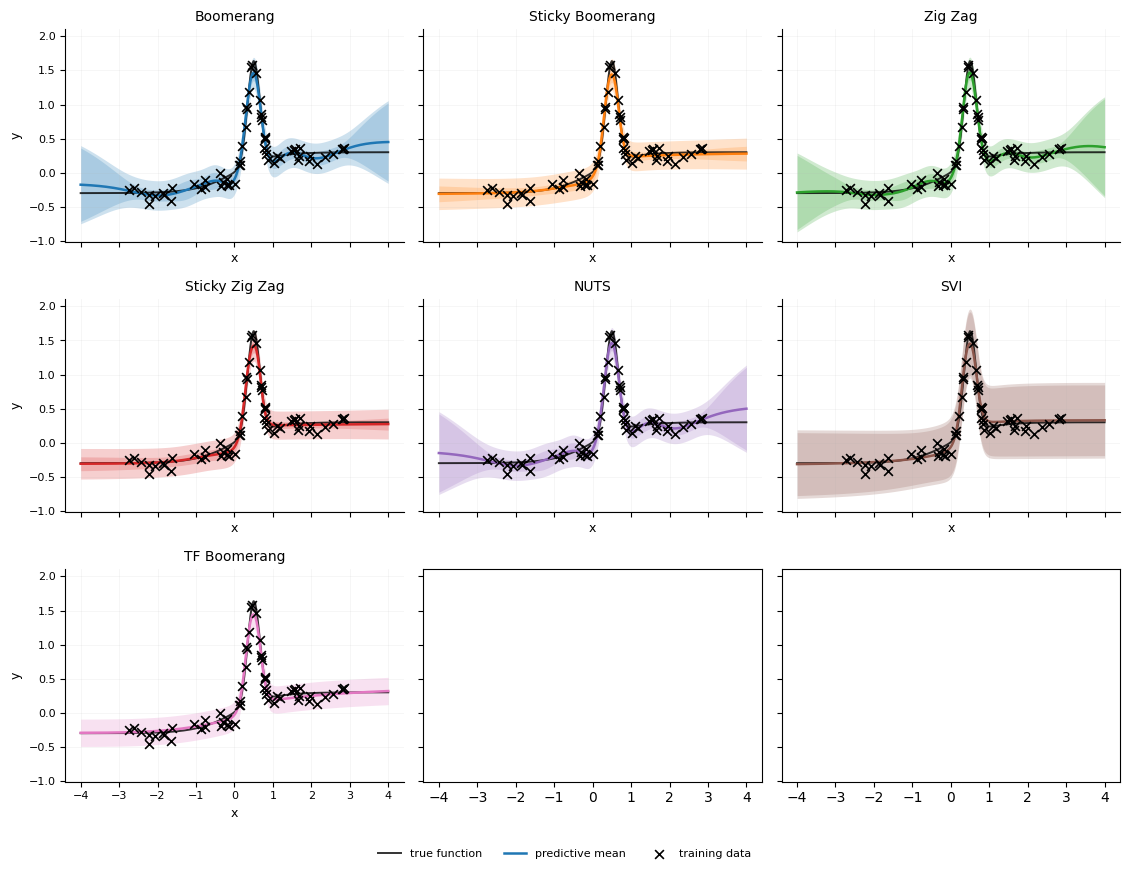

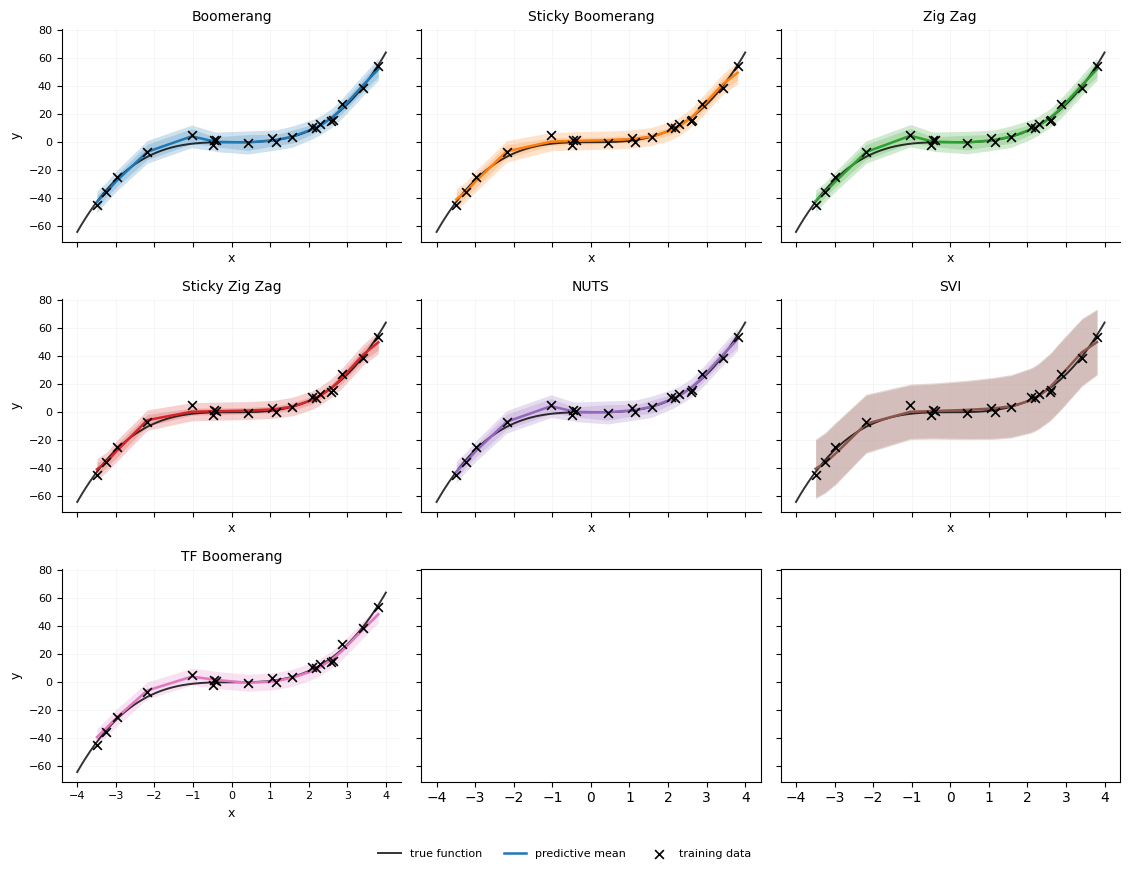

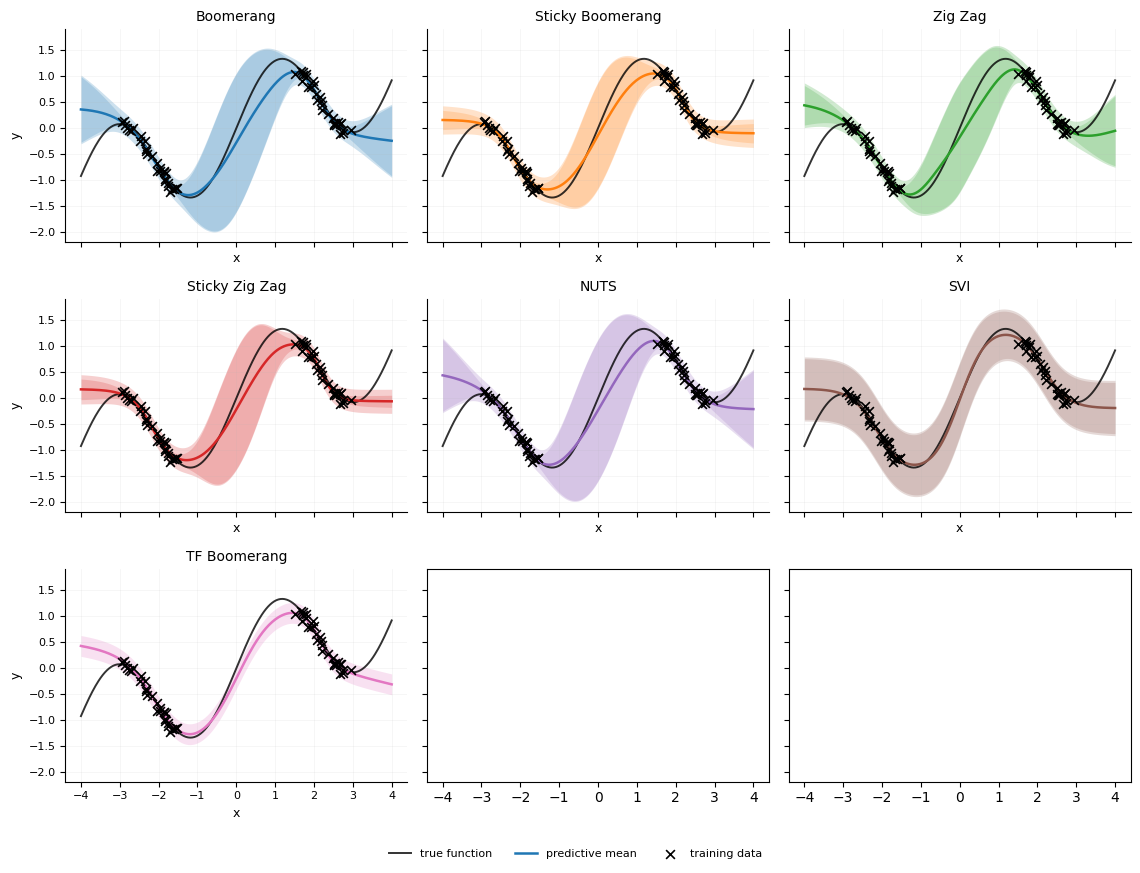

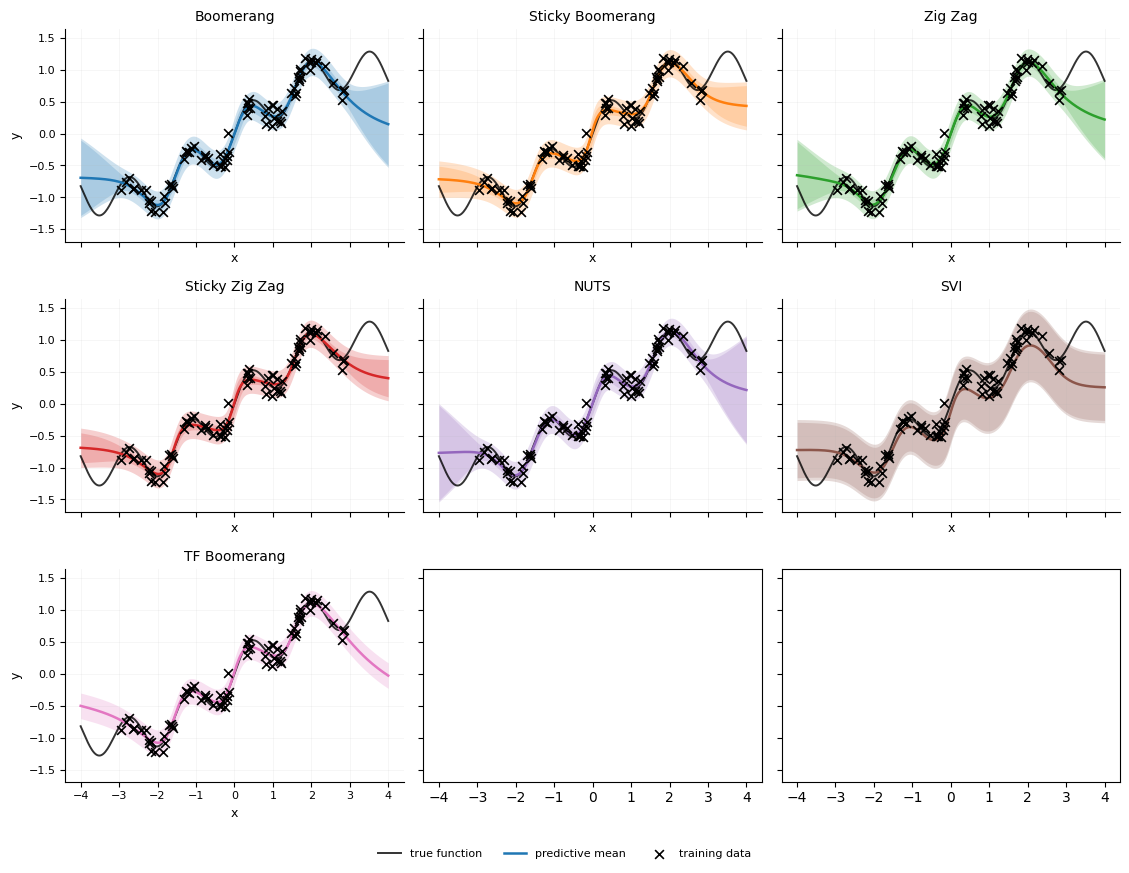

In [5]:
import math

for dataset in ['sharp', 'hernandez', 'gap', 'multiscale']:
    data, runs = load_split(dataset, 0)
    bm = make_bm_from_payload(next(iter(runs.values())), data, dataset)

    x_test  = data["x_test_raw"]
    y_true  = data["y_test_clean_raw"]
    x_train = data["x_train_raw"]
    y_train = data["y_train_raw"]

    if dataset == "hernandez":
        x_grid = np.sort(x_train)
    else:
        x_grid = np.sort(x_test)

    sort_idx = np.argsort(x_test)
    x_sorted = x_test[sort_idx]
    y_sorted = y_true[sort_idx]

    sampler_keys = [k for k in SAMPLER_STYLE if k in runs]
    n_cols = len(sampler_keys)

    # Was hardcoded to n_rows=3 (n_plot_cols=n_cols//3), sized for exactly
    # 6 samplers -- broke once Goan's tf_bps/tf_boomerang pushed some
    # datasets to 7-8. Keep the original 2-per-row shape for the
    # unchanged 6-sampler case, and grow the column count (not the row
    # count) to fit extra samplers, so existing datasets render exactly
    # as before and only datasets with more samplers get wider.
    n_plot_cols = math.ceil(n_cols / 3)
    n_rows = 3

    fig, axes = plt.subplots(
        n_rows,
        n_plot_cols,
        figsize=(3.8 * n_plot_cols, 2.8 * n_rows),
        sharey=True,
        sharex=True,
        squeeze=False,
    )

    for i, key in enumerate(sampler_keys):
        row, col = divmod(i, n_plot_cols)
        ax = axes[row, col]

        color, label = SAMPLER_STYLE[key]
        payload = runs[key]

        samples = payload["samples"]  # Tensor [S, D]

        mean, epi, total = predictive_summary(
            samples, bm, payload, data, x_grid
        )

        ax.fill_between(
            x_grid,
            mean - 2 * total,
            mean + 2 * total,
            color=color,
            alpha=0.22,
            linewidth=0,
        )

        ax.fill_between(
            x_grid,
            mean - 2 * epi,
            mean + 2 * epi,
            color=color,
            alpha=0.20,
            linewidth=0,
        )

        ax.plot(
            x_sorted,
            y_sorted,
            color="black",
            lw=1.4,
            alpha=0.8,
            zorder=3,
            label="true function",
        )

        ax.plot(
            x_grid,
            mean,
            color=color,
            lw=1.8,
            zorder=4,
            label="predictive mean",
        )

        ax.scatter(
            x_train,
            y_train,
            marker="x",
            color="black",
            s=40,
            linewidths=1.2,
            zorder=5,
            label="training data",
        )

        ax.set_title(label, fontsize=10)
        ax.set_xlabel("x", fontsize=9)

        if col == 0:
            ax.set_ylabel("y", fontsize=9)

        ax.tick_params(labelsize=8)
        ax.grid(alpha=0.15, linewidth=0.5)

        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)

    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=len(handles),
        frameon=False,
        fontsize=8,
        bbox_to_anchor=(0.5, -0.04),
    )

    #fig.suptitle(f"{dataset}", fontsize=11, y=1.01)

    fig.tight_layout()
    fig.savefig(fname=f"results/plots/toy_bnns/{dataset}.png")
    plt.show()

## Posterior sparsity

Effective dimension per posterior draw -- the number of weight coordinates that are *not* exactly zero. Sticky samplers freeze coordinates at zero as part of their dynamics, so a draw's zero pattern is exact; non-sticky samplers (and NUTS/SVI) essentially never land on exact zero, so their effective dimension sits at the full parameter count D. The noise/log-sigma coordinate (when learned) is excluded, since it is never subject to freezing.

In [6]:
# import pandas as pd
# eff_dim_records = []

# for dataset, split_id in available:
#     data, runs = load_split(dataset, split_id)
#     bm = make_bm_from_payload(next(iter(runs.values())), data, dataset)

#     for key in SAMPLER_STYLE:
#         if key not in runs:
#             continue
#         payload = runs[key]
#         samples = payload["samples"]
#         weight_samples = samples[:, :-1] if bm.learns_noise else samples

#         n_active = (weight_samples != 0).sum(dim=1).double()
#         eff_dim_records.append({
#             "dataset":  dataset,
#             "split_id": split_id,
#             "sampler":  key,
#             "eff_dim_mean": float(n_active.mean()),
#             "eff_dim_std":  float(n_active.std()),
#             "D": weight_samples.shape[1],
#         })

# eff_dim_df = pd.DataFrame(eff_dim_records)

# datasets_present = [ds for ds, _ in available]
# n_cols = len(datasets_present)

# fig, axes = plt.subplots(1, n_cols, figsize=(3.4 * n_cols, 3.4), squeeze=False)

# for col, (dataset, split_id) in enumerate(available):
#     ax = axes[0, col]
#     sub = eff_dim_df[(eff_dim_df["dataset"] == dataset) & (eff_dim_df["split_id"] == split_id)]
#     sampler_keys = [k for k in SAMPLER_STYLE if k in sub["sampler"].values]

#     xs = np.arange(len(sampler_keys))
#     D = int(sub["D"].iloc[0])

#     means = [float(sub[sub["sampler"] == k]["eff_dim_mean"].iloc[0]) for k in sampler_keys]
#     stds  = [float(sub[sub["sampler"] == k]["eff_dim_std"].iloc[0]) for k in sampler_keys]
#     colors = [SAMPLER_STYLE[k][0] for k in sampler_keys]

#     ax.bar(xs, means, yerr=stds, color=colors, alpha=0.85,
#            capsize=3, error_kw={"linewidth": 1})
#     ax.axhline(D, color="black", lw=1.0, ls="--", alpha=0.5)

#     ax.set_xticks(xs)
#     ax.set_xticklabels([SAMPLER_STYLE[k][1] for k in sampler_keys],
#                         rotation=40, ha="right", fontsize=8)
#     ax.set_title(dataset, fontsize=10)
#     if col == 0:
#         ax.set_ylabel("effective dimension", fontsize=9)
#     ax.set_ylim(0, D * 1.1)
#     ax.tick_params(labelsize=8)
#     ax.grid(axis="y", alpha=0.15, linewidth=0.5)
#     for spine in ("top", "right"):
#         ax.spines[spine].set_visible(False)

# fig.tight_layout()
# fig.savefig("results/plots/toy_bnns/effective_dimension.png", dpi=150, bbox_inches="tight")
# plt.show()

In [7]:
# import pandas as pd
# eff_dim_records = []

# for dataset, split_id in available:
#     data, runs = load_split(dataset, split_id)
#     bm = make_bm_from_payload(next(iter(runs.values())), data, dataset)

#     for key in SAMPLER_STYLE:
#         if key not in runs:
#             continue
#         payload = runs[key]
#         samples = payload["samples"]
#         weight_samples = samples[:, :-1] if bm.learns_noise else samples

#         n_active = (weight_samples != 0).sum(dim=1).double()
#         eff_dim_records.append({
#             "dataset":  dataset,
#             "split_id": split_id,
#             "sampler":  key,
#             "eff_dim_mean": float(n_active.mean()),
#             "eff_dim_std":  float(n_active.std()),
#             "D": weight_samples.shape[1],
#         })

# eff_dim_df = pd.DataFrame(eff_dim_records)

# n_rows, n_plot_cols = 2, 2
# fig, axes = plt.subplots(n_rows, n_plot_cols, figsize=(3.8 * n_plot_cols, 3.8 * n_rows), squeeze=False)
# fig.patch.set_facecolor("white")

# for idx, (dataset, split_id) in enumerate(available):
#     ax = axes[idx // n_plot_cols, idx % n_plot_cols]
#     sub = eff_dim_df[(eff_dim_df["dataset"] == dataset) & (eff_dim_df["split_id"] == split_id)]
#     sampler_keys = [k for k in SAMPLER_STYLE if k in sub["sampler"].values]

#     xs = np.arange(len(sampler_keys))
#     D = int(sub["D"].iloc[0])

#     means = [float(sub[sub["sampler"] == k]["eff_dim_mean"].iloc[0]) for k in sampler_keys]
#     stds  = [float(sub[sub["sampler"] == k]["eff_dim_std"].iloc[0]) for k in sampler_keys]
#     colors = [SAMPLER_STYLE[k][0] for k in sampler_keys]

#     ax.bar(xs, means, yerr=stds, color=colors, alpha=0.9, width=0.62,
#            edgecolor="white", linewidth=0.8,
#            capsize=3, error_kw={"linewidth": 1.1, "alpha": 0.6, "capthick": 1.1})

#     ax.axhline(D, color="#444444", lw=1.1, ls=(0, (4, 2)), alpha=0.7, zorder=1)

#     ax.set_xticks(xs)
#     ax.set_xticklabels([SAMPLER_STYLE[k][1] for k in sampler_keys],
#                         rotation=40, ha="right", fontsize=8.5)
#     ax.set_title(dataset, fontsize=11, pad=8)
#     ax.set_ylabel("effective dimension", fontsize=9.5)
#     ax.set_xlim(-0.6, len(sampler_keys) - 0.15)
#     ax.set_ylim(0, D * 1.15)
#     ax.tick_params(labelsize=8, length=0)
#     ax.grid(axis="y", alpha=0.2, linewidth=0.6, zorder=0)
#     ax.set_axisbelow(True)
#     for spine in ("top", "right", "left"):
#         ax.spines[spine].set_visible(False)
#     ax.spines["bottom"].set_color("#888888")
#     ax.spines["bottom"].set_linewidth(0.8)

# fig.tight_layout()
# fig.savefig("results/plots/toy_bnns/effective_dimension.png", dpi=150, bbox_inches="tight")
# plt.show()


## Predictive metrics

RMSE, NLL, CRPS, and 90%/95% coverage on the held-out (noisy) test set `X_test`/`y_test` -- not the dense plotting grid above, which uses the clean function for visualization only. Same formulas as `grid_uci_investigate.ipynb`. `ESS/grad` (ESS per gradient evaluation) is included since it's comparable across PDMP/NUTS despite their differing iteration/draw units; see the diagnostics section below for raw gradient-eval throughput.

In [8]:
import math
import pandas as pd
from torch.distributions import Normal

from sazz.utils.metrics import ess_per_coord


@torch.no_grad()
def predict_on_test(samples: torch.Tensor, bm, data) -> tuple[torch.Tensor, torch.Tensor, float]:
    """Returns (mean_pred, epist_std, noise_std) on the standardised test set."""
    X_test = data["X_test"].to(dtype=torch.float64)

    if bm.learns_noise:
        weight_samples = samples[:, :-1]
        noise_std = float(samples[:, -1].exp().mean())
    else:
        weight_samples = samples
        noise_std = float(data["noise_std"])

    preds = torch.stack([
        torch.func.functional_call(bm.module, bm.param_dict_fn(beta), (X_test,)).squeeze(-1)
        for beta in weight_samples
    ])  # [S, N]
    return preds.mean(0), preds.std(0), noise_std


def compute_rmse(y_true, mean_pred, y_std):
    return float(((mean_pred - y_true) ** 2).mean().sqrt()) * y_std


def compute_nll(y_true, mean_pred, total_std, y_std):
    ll = (-0.5 * ((y_true - mean_pred) / total_std) ** 2
          - total_std.log() - 0.5 * math.log(2 * math.pi)).mean()
    return float(-ll + math.log(y_std))


def compute_crps(y_true, mean_pred, total_std, y_std):
    d = Normal(0.0, 1.0)
    sigma = total_std * y_std
    z = (y_true * y_std - mean_pred * y_std) / sigma
    return float((sigma * (z * (2 * d.cdf(z) - 1) + 2 * d.log_prob(z).exp()
                            - 1 / math.sqrt(math.pi))).mean())


def compute_coverage(y_true, mean_pred, total_std, level=0.9):
    z = Normal(0.0, 1.0).icdf(torch.tensor(0.5 + level / 2))
    return float(((y_true - mean_pred).abs() <= z * total_std).float().mean())


metric_records = []

for dataset, split_id in available:
    data, runs = load_split(dataset, split_id)
    bm = make_bm_from_payload(next(iter(runs.values())), data, dataset)

    y_test = data["y_test"].to(dtype=torch.float64)
    y_std  = float(data["y_std"])

    for key in SAMPLER_STYLE:
        if key not in runs:
            continue
        payload = runs[key]
        samples = payload["samples"]
        mean_pred, epist_std, noise_std = predict_on_test(samples, bm, data)
        total_std = (epist_std ** 2 + noise_std ** 2).sqrt()

        weight_samples = samples[:, :-1] if bm.learns_noise else samples
        ess = ess_per_coord(weight_samples)
        grad_evals = payload.get("gradient_evals")

        metric_records.append({
            "dataset":  dataset,
            "split_id": split_id,
            "sampler":  SAMPLER_STYLE[key][1],
            "RMSE":     compute_rmse(y_test, mean_pred, y_std),
            "NLL":      compute_nll(y_test, mean_pred, total_std, y_std),
            "CRPS":     compute_crps(y_test, mean_pred, total_std, y_std),
            "Cov 90%":  compute_coverage(y_test, mean_pred, total_std, 0.90),
            "Cov 95%":  compute_coverage(y_test, mean_pred, total_std, 0.95),
        })

metrics_df = pd.DataFrame(metric_records).set_index(["dataset", "split_id", "sampler"])

NameError: name 'pd' is not defined

In [ ]:
def highlight_min_per_group(col):
    out = pd.Series("", index=col.index)
    for (dataset, split_id), group in col.groupby(level=("dataset", "split_id")):
        out.loc[group.idxmin()] = "background-color: #68dc0f"
    return out


def highlight_coverage(col):
    level = 0.90 if "90" in col.name else 0.95
    out = pd.Series("", index=col.index)
    for (dataset, split_id), group in col.groupby(level=("dataset", "split_id")):
        best = (group - level).abs().idxmin()
        out.loc[best] = "background-color: #68dc0f"
    return out


metrics_df.style \
    .apply(highlight_min_per_group, subset=["RMSE", "NLL", "CRPS"]) \
    .apply(highlight_coverage, subset=["Cov 90%", "Cov 95%"]) \
    .format(precision=4, na_rep="n/a")

## Sampler cost diagnostics (all samplers, all splits)

Compute-cost comparison across every `(dataset, split)` and sampler, in gradient evaluations of the log-target -- the common currency across PDMP "skeleton events" and NUTS "draws", which otherwise aren't comparable units. `t_max` columns are grid-sampler-only (NUTS has no adaptive horizon). `Grad evals`/`grid_t_max_log` are only present in `.pt` files saved after the runner scripts started persisting them -- older runs show `n/a`; re-run to backfill.

In [ ]:
diag_records = []

for dataset, split_id in available:
    _, runs = load_split(dataset, split_id)

    for key in SAMPLER_STYLE:
        if key not in runs:
            continue
        r = runs[key]

        n_events   = r.get("n_events")
        elapsed    = r.get("elapsed_sec")
        grad_evals = r.get("gradient_evals")
        t_max_log  = r.get("grid_t_max_log")
        bound_viol = r.get("bound_violations")

        diag_records.append({
            "dataset":          dataset,
            "split_id":         split_id,
            "sampler":          SAMPLER_STYLE[key][1],
            "Events/s":         (n_events / elapsed) if (n_events and elapsed) else float("nan"),
            "Grad evals/s":     (grad_evals / elapsed) if (grad_evals and elapsed) else float("nan"),
            "Grad evals/event": (grad_evals / n_events) if (grad_evals and n_events) else float("nan"),
            "t_max mean":       float(np.mean(t_max_log)) if t_max_log else float("nan"),
            "t_max min":        float(np.min(t_max_log)) if t_max_log else float("nan"),
            "t_max max":        float(np.max(t_max_log)) if t_max_log else float("nan"),
            "Bound violations": bound_viol if bound_viol is not None else float("nan"),
            "Time (s)":         elapsed if elapsed is not None else float("nan"),
        })

diag_df = pd.DataFrame(diag_records).set_index(["dataset", "split_id", "sampler"])
diag_df.style.format(precision=4, na_rep="n/a")

---
# Ablations: minibatching & negative-MAP initialisation

The cells above load a single result tree (`results/grid/toy_bnns`, the
full-batch runs). The cells below compare that against two ablations that
write to their own trees:

| key | tree | script |
|---|---|---|
| `fullbatch` | `results/grid/toy_bnns` | `toy_bnn_grid.py` |
| `minibatch` | `results/paper/toy_bnns_minibatch` | `toy_bnn_grid_minibatch.py --grad-batch-size B` |
| `negmap`    | `results/paper/toy_bnns_negative_map` | `toy_bnn_grid_negative_map.py` |

`negmap` starts every grid sampler from the **mirror MAP** — `x_ref` with
the first layer's weights+biases and the second layer's weights sign-flipped
(the output bias kept). `tanh` is odd, so that map is exactly
energy-preserving: a distinct, equally-good posterior mode.

Everything below **degrades gracefully**: a tree that does not exist yet
(you have not run that script) is simply skipped, with a note.


In [ ]:
import pandas as pd

# Result trees for the three arms. Add split ids here if you run more.
RUN_TREES = {
    "fullbatch": Path("results/grid/toy_bnns"),
    "minibatch": Path("results/paper/toy_bnns_minibatch"),
    "negmap":    Path("results/paper/toy_bnns_negative_map"),
}
RUN_STYLE = {
    "fullbatch": ("full batch",  "-",  1.6),
    "minibatch": ("minibatch",   "--", 1.3),
    "negmap":    ("neg-MAP init", ":",  1.6),
}
GRID_SAMPLERS = ["grid_boomerang", "grid_sticky_boomerang", "grid_zigzag", "grid_sticky_zigzag"]

RUNS_PRESENT = {k: v for k, v in RUN_TREES.items() if v.is_dir()}
for k, v in RUN_TREES.items():
    status = "found" if k in RUNS_PRESENT else "MISSING - run its script first"
    print(f"  {k:10s} {str(v):42s} {status}")


def discover(tree: Path):
    """(dataset, split) pairs with at least one grid sampler .pt under `tree`."""
    out = set()
    for p in tree.glob("*/split_*/*.pt"):
        if p.stem in GRID_SAMPLERS:
            out.add((p.parent.parent.name, int(p.parent.name.split("_")[1])))
    return sorted(out)


def load_run(run_key: str, dataset: str, split_id: int, sampler: str):
    """Payload dict, or None if that (run, dataset, split, sampler) is absent."""
    tree = RUN_TREES.get(run_key)
    if tree is None:
        return None
    p = tree / dataset / f"split_{split_id:02d}" / f"{sampler}.pt"
    if not p.exists():
        return None
    return torch.load(p, weights_only=False)


# union of (dataset, split) across whatever trees exist
ABLATION_AVAILABLE = sorted(set().union(*(set(discover(v)) for v in RUNS_PRESENT.values())) if RUNS_PRESENT else set())
print("\n(dataset, split) available in >=1 tree:", ABLATION_AVAILABLE)


## Minibatch ablation

For every `(dataset, split, grid sampler)`: bound violations and predictive
metrics, `fullbatch` vs `minibatch` side by side. The headline number is
**bound violations** — a nonzero count means the grid upper bound the
sampler relied on was *not actually valid* in at least one window, i.e. the
subsampled gradient broke the thinning guarantee. `grad_batch_size` is read
back from the minibatch payloads.


In [ ]:
from torch.distributions import Normal as _Normal
import math as _math

# reuse make_bm_from_payload / predict_on_test / compute_* from the cells above


def _predictive_metrics(payload, bm, data):
    y_test = data["y_test"].to(dtype=torch.float64)
    y_std  = float(data["y_std"])
    samples = payload["samples"]
    mean_pred, epist_std, noise_std = predict_on_test(samples, bm, data)
    total_std = (epist_std ** 2 + noise_std ** 2).sqrt()
    return {
        "RMSE":    compute_rmse(y_test, mean_pred, y_std),
        "NLL":     compute_nll(y_test, mean_pred, total_std, y_std),
        "CRPS":    compute_crps(y_test, mean_pred, total_std, y_std),
        "Cov 90%": compute_coverage(y_test, mean_pred, total_std, 0.90),
    }


mb_records = []
if "minibatch" in RUNS_PRESENT:
    for dataset, split_id in ABLATION_AVAILABLE:
        data, _ = load_split(dataset, split_id) if (RESULTS_DIR / dataset / f"split_{split_id:02d}").is_dir() \
                  else (torch.load(DATA_DIR / f"{dataset}.pt", weights_only=False), None)
        bm = None
        for sampler in GRID_SAMPLERS:
            fb = load_run("fullbatch", dataset, split_id, sampler)
            mb = load_run("minibatch", dataset, split_id, sampler)
            if mb is None:
                continue
            if bm is None:
                bm = make_bm_from_payload(mb, data, dataset)
            row = {
                "dataset": dataset, "split": split_id,
                "sampler": SAMPLER_STYLE.get(sampler, (None, sampler))[1],
                "batch": mb.get("grad_batch_size"),
                "viol (mb)": mb.get("bound_violations"),
                "viol (fb)": fb.get("bound_violations") if fb else float("nan"),
                "n_events (mb)": mb.get("n_events"),
            }
            mmb = _predictive_metrics(mb, bm, data)
            row.update({f"{k} (mb)": v for k, v in mmb.items()})
            if fb is not None:
                mfb = _predictive_metrics(fb, bm, data)
                row.update({f"{k} (fb)": v for k, v in mfb.items()})
            mb_records.append(row)

if mb_records:
    mb_df = pd.DataFrame(mb_records).set_index(["dataset", "split", "sampler"])
    cols = ["batch", "viol (fb)", "viol (mb)", "n_events (mb)",
            "RMSE (fb)", "RMSE (mb)", "NLL (fb)", "NLL (mb)",
            "CRPS (fb)", "CRPS (mb)", "Cov 90% (fb)", "Cov 90% (mb)"]
    cols = [c for c in cols if c in mb_df.columns]
    display(mb_df[cols].style.format(precision=4, na_rep="n/a")
            .apply(lambda s: ["background-color: #ffd0d0" if (isinstance(v, (int, float)) and v and v > 0) else ""
                              for v in s], subset=[c for c in ["viol (mb)", "viol (fb)"] if c in cols]))
else:
    print("No minibatch results found - run:\n"
          "  python -m sazz.gpu_friendly.scripts.toy_bnn_grid_minibatch --grad-batch-size 16")


In [ ]:
# Minibatch vs full-batch predictive envelopes, per dataset (grid samplers only)
if "minibatch" in RUNS_PRESENT:
    for dataset, split_id in ABLATION_AVAILABLE:
        data = torch.load(DATA_DIR / f"{dataset}.pt", weights_only=False)
        pairs = [(s, load_run("fullbatch", dataset, split_id, s), load_run("minibatch", dataset, split_id, s))
                 for s in GRID_SAMPLERS]
        pairs = [(s, fb, mb) for (s, fb, mb) in pairs if mb is not None]
        if not pairs:
            continue
        bm = make_bm_from_payload(pairs[0][2], data, dataset)

        x_train, y_train = data["x_train_raw"], data["y_train_raw"]
        x_test, y_true = data["x_test_raw"], data["y_test_clean_raw"]
        x_grid = np.sort(x_train if dataset == "hernandez" else x_test)
        si = np.argsort(x_test)

        fig, axes = plt.subplots(1, len(pairs), figsize=(3.7 * len(pairs), 3.4),
                                 sharey=True, squeeze=False)
        for col, (sampler, fb, mb) in enumerate(pairs):
            ax = axes[0, col]
            base_color, label = SAMPLER_STYLE.get(sampler, ("C0", sampler))
            for payload, (rlabel, ls, lw), c in [(fb, RUN_STYLE["fullbatch"], "black"),
                                                 (mb, RUN_STYLE["minibatch"], base_color)]:
                if payload is None:
                    continue
                mean, epi, total = predictive_summary(payload["samples"], bm, payload, data, x_grid)
                ax.plot(x_grid, mean, color=c, ls=ls, lw=lw, zorder=4,
                        label=f"{rlabel} mean")
                ax.fill_between(x_grid, mean - 2 * total, mean + 2 * total,
                                color=c, alpha=0.12, linewidth=0)
            ax.plot(x_test[si], y_true[si], color="0.5", lw=1.2, zorder=3)
            ax.scatter(x_train, y_train, marker="x", color="black", s=25, linewidths=1, zorder=5)
            viol = mb.get("bound_violations")
            ax.set_title(f"{label}\nmb viol={viol}", fontsize=9)
            ax.set_xlabel("x", fontsize=8)
            ax.tick_params(labelsize=7)
            for sp in ("top", "right"):
                ax.spines[sp].set_visible(False)
        axes[0, 0].legend(fontsize=7, frameon=False)
        fig.suptitle(f"{dataset} - full batch vs minibatch (batch={pairs[0][2].get('grad_batch_size')})",
                     fontsize=10, y=1.02)
        fig.tight_layout()
        plt.show()
else:
    print("skipped - no minibatch tree")


## Negative-MAP initialisation

`negmap` starts each grid sampler at the mirror mode. Two things to look
at:

1. **Does the chain stay there, cross back, or explore both?** The cleanest
   scalar for this is the *mirror projection*
   $m(\beta) = \langle \beta_{\text{flip}},\, \mathrm{sign}(x_{\text{ref,flip}}) \rangle / \lVert x_{\text{ref,flip}} \rVert_1$,
   computed over the sign-flipped coordinate block. It is $\approx +1$ deep
   in the positive mode, $\approx -1$ deep in the mirror mode, $\approx 0$
   at a symmetric point between them. `negmap` runs start near $-1$; a
   `fullbatch` run of the same sampler is overlaid for reference.
2. **Trace plots** of that projection, of $\lVert\beta\rVert$, and of a few
   raw coordinates.

If `results/paper/toy_bnns_negative_map/` does not exist yet this whole
section prints a note and does nothing.


In [ ]:
NEGMAP_READY = "negmap" in RUNS_PRESENT
if not NEGMAP_READY:
    print("No negative-MAP results yet. Run e.g.:\n"
          "  python -m sazz.gpu_friendly.scripts.toy_bnn_grid_negative_map\n"
          "  python -m sazz.gpu_friendly.scripts.toy_bnn_grid_negative_map --grad-batch-size 16\n"
          "then re-run the cells below.")


def flip_mask(bm):
    """Bool [D] mask of sign-flipped coords for the single-hidden-layer tanh
    FFN: every parameter except the last Linear's bias. Mirrors
    build_negate_mask in toy_bnn_grid_negative_map.py."""
    names = [n for n, _ in bm.module.named_parameters()]
    last_bias = f"layers.{max(int(n.split('.')[1]) for n in names if n.startswith('layers.'))}.bias"
    mask = torch.zeros(bm.D, dtype=torch.bool)
    idx = 0
    for name, p in bm.module.named_parameters():
        n = p.numel()
        if name != last_bias:
            mask[idx:idx + n] = True
        idx += n
    return mask


def mirror_projection(samples: torch.Tensor, mask: torch.Tensor, x_ref_pos: torch.Tensor):
    """<beta_flip, sign(x_ref_pos_flip)> / ||x_ref_pos_flip||_1  in [-~1, +~1].
    +1 deep in the positive mode, -1 deep in the mirror mode."""
    s = torch.sign(x_ref_pos[mask])
    denom = x_ref_pos[mask].abs().sum().clamp_min(1e-12)
    return (samples[:, mask].double() * s).sum(dim=1) / denom


def reference_x_refs(dataset, split_id, bm, data):
    """(x_ref_pos, x_ref_neg): the positive MAP and its mirror. Prefers the
    x_ref stored in a fullbatch/minibatch payload (that IS the positive
    mode); only re-runs build_target if neither arm exists for this
    (dataset, split)."""
    x_ref_pos = None
    for run_key in ("fullbatch", "minibatch"):
        for sampler in GRID_SAMPLERS:
            p = load_run(run_key, dataset, split_id, sampler)
            if p is not None and p.get("x_ref") is not None:
                x_ref_pos = p["x_ref"].double()
                break
        if x_ref_pos is not None:
            break
    if x_ref_pos is None:
        _, x_ref_pos, _ = build_target(
            data, BNNConfig(**DATASET_CONFIGS[dataset], noise_std=data["noise_std"]))
        x_ref_pos = x_ref_pos.double()
    m = flip_mask(bm)
    x_ref_neg = torch.where(m, -x_ref_pos, x_ref_pos)
    return x_ref_pos, x_ref_neg


In [ ]:
# Mirror-projection summary: for each (dataset, sampler), the projection's
# mean +/- std under each available run arm.
if NEGMAP_READY:
    proj_records = []
    for dataset, split_id in ABLATION_AVAILABLE:
        data = torch.load(DATA_DIR / f"{dataset}.pt", weights_only=False)
        any_payload = next((load_run(r, dataset, split_id, s)
                            for s in GRID_SAMPLERS for r in RUN_STYLE
                            if load_run(r, dataset, split_id, s) is not None), None)
        if any_payload is None:
            continue
        bm = make_bm_from_payload(any_payload, data, dataset)
        mask = flip_mask(bm)
        x_ref_pos, _ = reference_x_refs(dataset, split_id, bm, data)
        for sampler in GRID_SAMPLERS:
            for run_key in RUN_STYLE:
                payload = load_run(run_key, dataset, split_id, sampler)
                if payload is None:
                    continue
                proj = mirror_projection(payload["samples"], mask, x_ref_pos)
                proj_records.append({
                    "dataset": dataset, "sampler": SAMPLER_STYLE.get(sampler, (None, sampler))[1],
                    "run": RUN_STYLE[run_key][0],
                    "proj mean": float(proj.mean()), "proj std": float(proj.std()),
                    "proj min": float(proj.min()), "proj max": float(proj.max()),
                    "frac >0": float((proj > 0).float().mean()),
                    "viol": payload.get("bound_violations"),
                })
    proj_df = pd.DataFrame(proj_records).set_index(["dataset", "sampler", "run"])
    display(proj_df.style.format(precision=3, na_rep="n/a")
            .background_gradient(subset=["proj mean"], cmap="coolwarm", vmin=-1, vmax=1))
else:
    print("skipped")


In [ ]:
# Trace plots: mirror projection + ||beta|| + a few raw coords, per (dataset, sampler),
# every available run arm overlaid.
TRACE_COORDS = 3  # number of raw beta coordinates to trace

if RUNS_PRESENT:
    for dataset, split_id in ABLATION_AVAILABLE:
        data = torch.load(DATA_DIR / f"{dataset}.pt", weights_only=False)
        # need a bm + positive x_ref for the projection axis
        any_payload = next((load_run(r, dataset, split_id, s)
                            for s in GRID_SAMPLERS for r in RUN_STYLE
                            if load_run(r, dataset, split_id, s) is not None), None)
        if any_payload is None:
            continue
        bm = make_bm_from_payload(any_payload, data, dataset)
        mask = flip_mask(bm)
        x_ref_pos, x_ref_neg = reference_x_refs(dataset, split_id, bm, data)
        coord_idx = torch.linspace(0, bm.D - 1, TRACE_COORDS + 2)[1:-1].round().long().tolist()

        for sampler in GRID_SAMPLERS:
            arms = [(r, load_run(r, dataset, split_id, sampler)) for r in RUN_STYLE]
            arms = [(r, p) for (r, p) in arms if p is not None]
            if not arms:
                continue

            n_panels = 2 + TRACE_COORDS
            fig, axes = plt.subplots(n_panels, 1, figsize=(9, 1.9 * n_panels), sharex=True)
            label = SAMPLER_STYLE.get(sampler, (None, sampler))[1]

            for run_key, payload in arms:
                s = payload["samples"].double()
                rlabel, ls, lw = RUN_STYLE[run_key]
                color = {"fullbatch": "black", "minibatch": "C1", "negmap": "C3"}[run_key]
                draws = np.arange(s.shape[0])

                axes[0].plot(draws, mirror_projection(s, mask, x_ref_pos),
                             color=color, ls=ls, lw=lw, label=rlabel, alpha=0.9)
                axes[1].plot(draws, s.norm(dim=1), color=color, ls=ls, lw=lw, alpha=0.9)
                for k, ci in enumerate(coord_idx):
                    axes[2 + k].plot(draws, s[:, ci], color=color, ls=ls, lw=lw, alpha=0.9)

            axes[0].axhline(0.0, color="0.6", lw=0.8, ls="-")
            axes[0].axhline(1.0, color="0.8", lw=0.8, ls=":")
            axes[0].axhline(-1.0, color="0.8", lw=0.8, ls=":")
            axes[0].set_ylabel("mirror\nprojection", fontsize=8)
            axes[0].set_title(f"{dataset} - {label}  (split {split_id})  "
                              f"[-- = positive MAP coord,  : = mirror MAP coord]", fontsize=9)
            axes[1].set_ylabel(r"$\|\beta\|$", fontsize=8)
            for k, ci in enumerate(coord_idx):
                axes[2 + k].axhline(float(x_ref_pos[ci]), color="0.55", lw=0.8, ls="--")
                axes[2 + k].axhline(float(x_ref_neg[ci]), color="0.8", lw=0.8, ls=":")
                axes[2 + k].set_ylabel(f"$\\beta_{{{ci}}}$", fontsize=8)
            axes[-1].set_xlabel("posterior draw index (thinned)", fontsize=8)
            axes[0].legend(fontsize=7, frameon=False, ncol=len(arms))
            for ax in axes:
                ax.tick_params(labelsize=7)
                for sp in ("top", "right"):
                    ax.spines[sp].set_visible(False)
            fig.tight_layout()
            plt.show()
else:
    print("no result trees present at all")


In [ ]:
# Cross-arm cost / validity diagnostics (grid samplers only)
if RUNS_PRESENT:
    xrec = []
    for dataset, split_id in ABLATION_AVAILABLE:
        for sampler in GRID_SAMPLERS:
            for run_key in RUN_STYLE:
                p = load_run(run_key, dataset, split_id, sampler)
                if p is None:
                    continue
                n_ev, el = p.get("n_events"), p.get("elapsed_sec")
                ge = p.get("gradient_evals")
                tml = p.get("grid_t_max_log")
                xrec.append({
                    "dataset": dataset, "split": split_id,
                    "sampler": SAMPLER_STYLE.get(sampler, (None, sampler))[1],
                    "run": RUN_STYLE[run_key][0],
                    "batch": p.get("grad_batch_size"),
                    "bound viol": p.get("bound_violations"),
                    "n_events": n_ev,
                    "grad/event": (ge / n_ev) if (ge and n_ev) else float("nan"),
                    "events/s": (n_ev / el) if (n_ev and el) else float("nan"),
                    "t_max mean": float(np.mean(tml)) if tml else float("nan"),
                    "t_max min": float(np.min(tml)) if tml else float("nan"),
                    "time (s)": el if el is not None else float("nan"),
                })
    xdf = pd.DataFrame(xrec).set_index(["dataset", "split", "sampler", "run"]).sort_index()
    display(xdf.style.format(precision=3, na_rep="n/a")
            .apply(lambda s: ["background-color: #ffd0d0" if (isinstance(v, (int, float)) and v and v > 0) else ""
                              for v in s], subset=["bound viol"]))
else:
    print("no result trees present")
